In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('ecuador_empleo_pobreza_2007_2024.csv', index_col='año')

C1, C2, C3, C4 = '#E63946', '#457B9D', '#2D6A4F', '#F4A261'

plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 130
})

print(f"✓ Dataset cargado: {df.shape}")
print(f"  Período: {df.index.min()} – {df.index.max()}")

✓ Dataset cargado: (18, 19)
  Período: 2007 – 2024


In [2]:
features = [
    'gini_inec',               # Desigualdad     (corr: 0.91)
    'ingreso_laboral_promedio', # Ingresos         (corr: 0.89)
    'pib_per_capita_usd',      # Economía         (corr: 0.86)
    'desempleo_pct',           # Mercado laboral  (corr: 0.72)
    'informalidad_pct',        # Informalidad     (corr: 0.66)
    'salario_basico_usd',      # Política salarial(corr: 0.69)
]

target = 'pobreza_ingresos_pct'

df_model = df[features + [target]].dropna()

print(f"✓ Dataset para modelado: {df_model.shape[0]} observaciones")
print(f"  Años disponibles: {list(df_model.index)}")
print(f"\nCorrelación de cada feature con la variable objetivo:")
for f in features:
    corr = df_model[f].corr(df_model[target])
    print(f"  - {f}: r = {corr:.2f}")

X = df_model[features]
y = df_model[target]

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=features,
    index=X.index
)

print(f"\n✓ Features escaladas para modelos regularizados")

✓ Dataset para modelado: 14 observaciones
  Años disponibles: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

Correlación de cada feature con la variable objetivo:
  - gini_inec: r = 0.81
  - ingreso_laboral_promedio: r = -0.89
  - pib_per_capita_usd: r = -0.41
  - desempleo_pct: r = 0.03
  - informalidad_pct: r = 0.66
  - salario_basico_usd: r = 0.05

✓ Features escaladas para modelos regularizados


In [3]:
print("=" * 60)
print("NOTA METODOLÓGICA — VALIDACIÓN DEL MODELO")
print("=" * 60)
print(f"""
Dataset: {len(df_model)} observaciones (años 2011–2024)
Técnica: Leave-One-Out Cross Validation (LOOCV)

Por qué LOOCV:
  - Con N=14, un split 80/20 deja solo 3 años de prueba
    → resultados inestables e irreproducibles.
  - LOOCV entrena con N-1 años y predice el restante
    en cada iteración → usa todos los datos disponibles.
  - Es el estándar académico para series temporales cortas.

Cálculo del R²:
  - NO se usa cross_val_score con scoring='r2' porque
    promedia R² individuales por fold → puede dar NaN
    cuando algún fold tiene R² negativo.
  - SÍ se calcula r2_score() sobre TODAS las predicciones
    LOOCV concatenadas vs los valores reales → correcto.
""")
print("=" * 60)

NOTA METODOLÓGICA — VALIDACIÓN DEL MODELO

Dataset: 14 observaciones (años 2011–2024)
Técnica: Leave-One-Out Cross Validation (LOOCV)

Por qué LOOCV:
  - Con N=14, un split 80/20 deja solo 3 años de prueba
    → resultados inestables e irreproducibles.
  - LOOCV entrena con N-1 años y predice el restante
    en cada iteración → usa todos los datos disponibles.
  - Es el estándar académico para series temporales cortas.

Cálculo del R²:
  - NO se usa cross_val_score con scoring='r2' porque
    promedia R² individuales por fold → puede dar NaN
    cuando algún fold tiene R² negativo.
  - SÍ se calcula r2_score() sobre TODAS las predicciones
    LOOCV concatenadas vs los valores reales → correcto.



In [4]:
def evaluar_modelo_loocv(nombre, modelo, X_input, y):
    """
    Evalúa un modelo con LOOCV calculando el R² correctamente:
    sobre todas las predicciones concatenadas, no promediando
    R² individuales por fold.
    """
    loo = LeaveOneOut()
    y_pred_list = []
    y_real_list = []

    for train_idx, test_idx in loo.split(X_input):
        X_train = X_input.iloc[train_idx]
        X_test  = X_input.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test  = y.iloc[test_idx]

        modelo_temp = type(modelo)(**modelo.get_params())
        modelo_temp.fit(X_train, y_train)
        y_pred_list.append(modelo_temp.predict(X_test)[0])
        y_real_list.append(y_test.values[0])

    y_pred_arr = np.array(y_pred_list)
    y_real_arr = np.array(y_real_list)

    # R² calculado sobre predicciones concatenadas (método correcto)
    r2  = r2_score(y_real_arr, y_pred_arr)
    mae = mean_absolute_error(y_real_arr, y_pred_arr)
    rmse = np.sqrt(mean_squared_error(y_real_arr, y_pred_arr))

    return {
        'Modelo': nombre,
        'R²': round(r2, 3),
        'MAE (pp)': round(mae, 3),
        'RMSE (pp)': round(rmse, 3),
        'y_pred': y_pred_arr,
        'y_real': y_real_arr,
    }

print("✓ Función LOOCV definida (R² calculado correctamente)")

✓ Función LOOCV definida (R² calculado correctamente)


In [5]:
modelos = {
    'Regresión Lineal': LinearRegression(),
    'Ridge (L2)':       Ridge(alpha=1.0),
    'Lasso (L1)':       Lasso(alpha=0.5),
    'Random Forest':    RandomForestRegressor(
                            n_estimators=100, max_depth=3,
                            random_state=42),
    'Gradient Boosting':GradientBoostingRegressor(
                            n_estimators=100, max_depth=2,
                            learning_rate=0.1, random_state=42),
}

# Modelos que usan features escaladas
modelos_escalados = {'Regresión Lineal', 'Ridge (L2)', 'Lasso (L1)'}

print("Entrenando modelos con LOOCV...\n")
resultados = []

for nombre, modelo in modelos.items():
    X_input = X_scaled if nombre in modelos_escalados else X
    res = evaluar_modelo_loocv(nombre, modelo, X_input, y)
    resultados.append(res)
    print(f"  ✓ {nombre}")
    print(f"    R²={res['R²']:.3f} | MAE={res['MAE (pp)']:.3f}pp "
          f"| RMSE={res['RMSE (pp)']:.3f}pp")

df_resultados = (pd.DataFrame(resultados)
                 .drop(columns=['y_pred','y_real'])
                 .sort_values('R²', ascending=False)
                 .reset_index(drop=True))

print(f"\n{'='*55}")
print("RANKING DE MODELOS — LOOCV (R² calculado correctamente)")
print('='*55)
print(df_resultados.to_string(index=False))

Entrenando modelos con LOOCV...

  ✓ Regresión Lineal
    R²=0.903 | MAE=0.717pp | RMSE=0.888pp
  ✓ Ridge (L2)
    R²=0.892 | MAE=0.796pp | RMSE=0.935pp
  ✓ Lasso (L1)
    R²=0.681 | MAE=1.263pp | RMSE=1.609pp
  ✓ Random Forest
    R²=0.513 | MAE=1.504pp | RMSE=1.988pp
  ✓ Gradient Boosting
    R²=0.588 | MAE=1.467pp | RMSE=1.828pp

RANKING DE MODELOS — LOOCV (R² calculado correctamente)
           Modelo    R²  MAE (pp)  RMSE (pp)
 Regresión Lineal 0.903     0.717      0.888
       Ridge (L2) 0.892     0.796      0.935
       Lasso (L1) 0.681     1.263      1.609
Gradient Boosting 0.588     1.467      1.828
    Random Forest 0.513     1.504      1.988


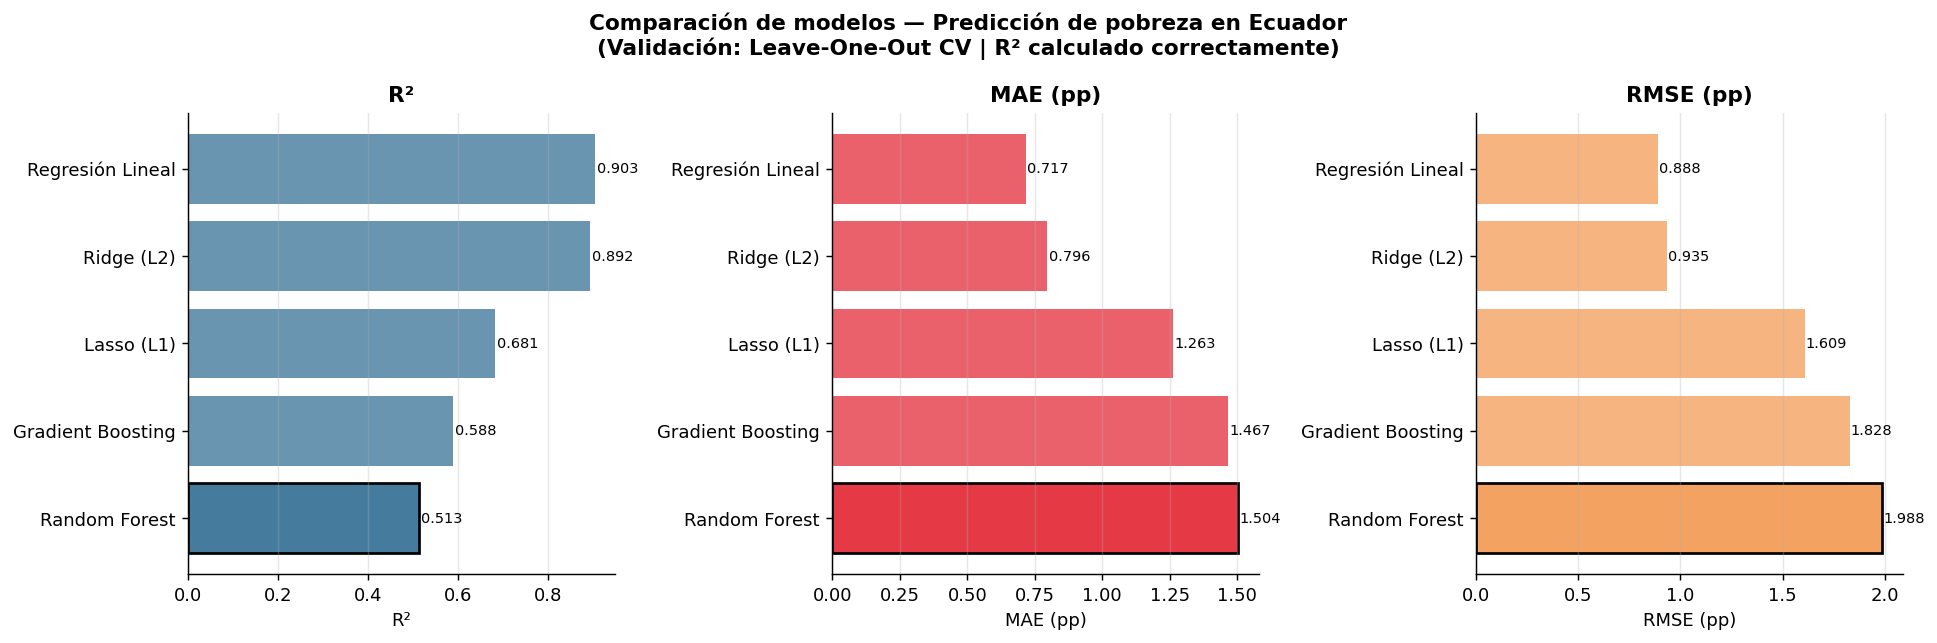

✓ Gráfico 06 guardado


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metricas   = ['R²', 'MAE (pp)', 'RMSE (pp)']
colores    = [C2, C1, C4]
mayor_mejor = [True, False, False]

for i, (metrica, color, asc) in enumerate(
        zip(metricas, colores, mayor_mejor)):

    ax = axes[i]
    df_plot = df_resultados.sort_values(metrica, ascending=asc)
    bars = ax.barh(df_plot['Modelo'], df_plot[metrica],
                   color=color, alpha=0.8)

    # Destacar el mejor
    bars[0].set_alpha(1.0)
    bars[0].set_edgecolor('black')
    bars[0].set_linewidth(1.5)

    for bar, val in zip(bars, df_plot[metrica]):
        ax.text(bar.get_width() + 0.005,
                bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

    ax.set_title(metrica, fontweight='bold')
    ax.set_xlabel(metrica)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Comparación de modelos — Predicción de pobreza en Ecuador\n'
             '(Validación: Leave-One-Out CV | R² calculado correctamente)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('06_comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico 06 guardado")

✓ Mejor modelo: Regresión Lineal
  R²   = 0.903
  MAE  = 0.717 pp
  RMSE = 0.888 pp


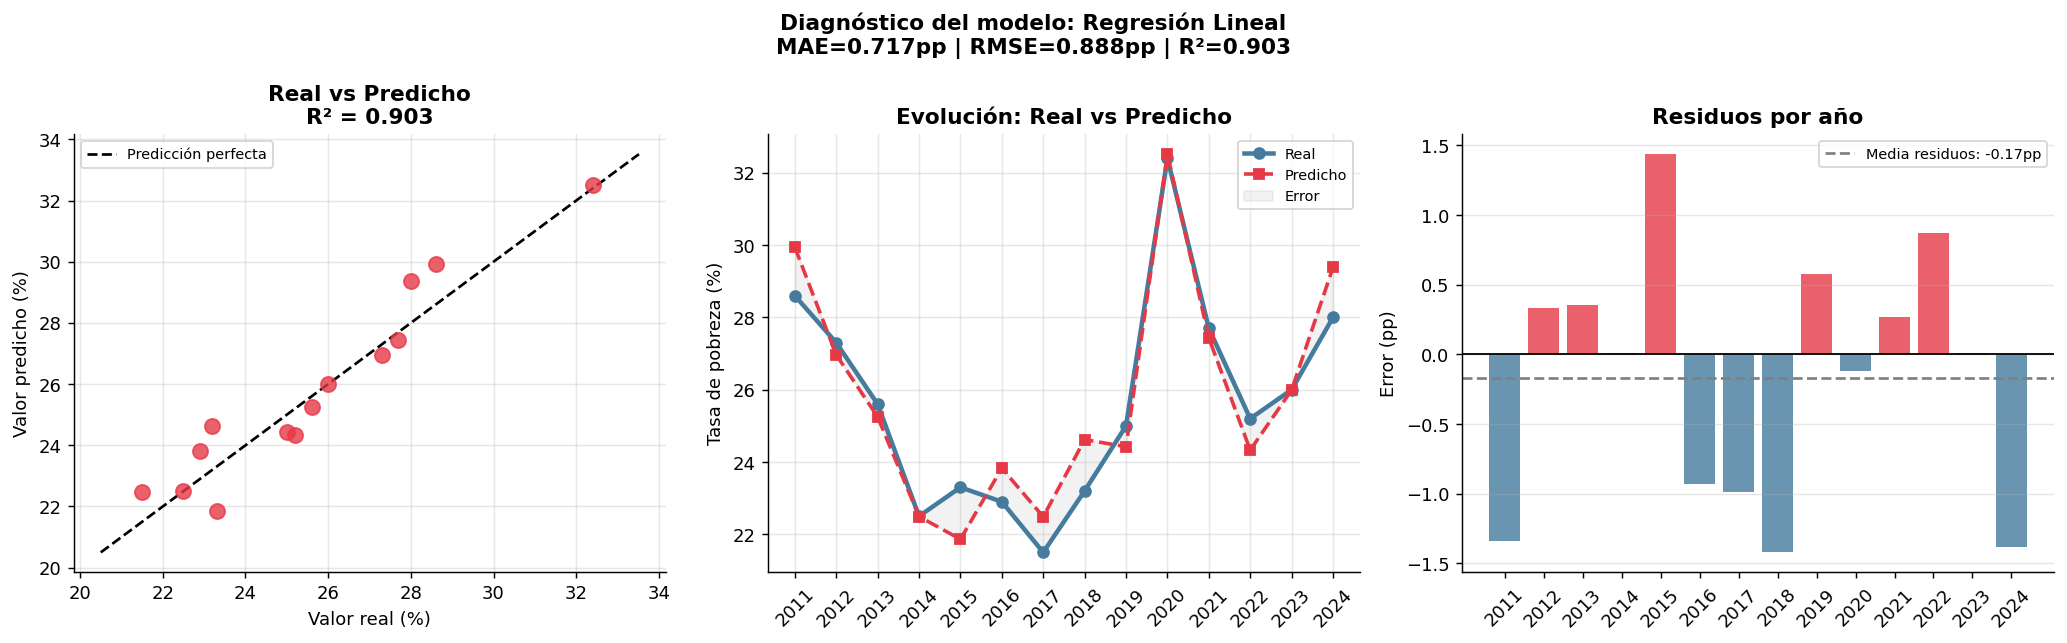


📊 HALLAZGO 6:
  El modelo Regresión Lineal predice la tasa de pobreza
  con un error promedio de 0.717 pp
  y un R² = 0.903 (90.3% de varianza explicada)


In [7]:
# Identificar mejor modelo por R²
mejor_nombre = df_resultados.iloc[0]['Modelo']
mejor_res    = next(r for r in resultados if r['Modelo'] == mejor_nombre)
mejor_modelo = modelos[mejor_nombre]
X_input      = X_scaled if mejor_nombre in modelos_escalados else X

print(f"✓ Mejor modelo: {mejor_nombre}")
print(f"  R²   = {mejor_res['R²']:.3f}")
print(f"  MAE  = {mejor_res['MAE (pp)']:.3f} pp")
print(f"  RMSE = {mejor_res['RMSE (pp)']:.3f} pp")

y_pred_loo = mejor_res['y_pred']
y_real_loo = mejor_res['y_real']
años_model = df_model.index

# Reentrenar con todos los datos para análisis posterior
mejor_modelo.fit(X_input, y)

# ── Gráficos de diagnóstico ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Real vs Predicho
ax = axes[0]
ax.scatter(y_real_loo, y_pred_loo,
           color=C1, s=70, alpha=0.8, zorder=3)
lim = [min(y_real_loo.min(), y_pred_loo.min()) - 1,
       max(y_real_loo.max(), y_pred_loo.max()) + 1]
ax.plot(lim, lim, 'k--', lw=1.5, label='Predicción perfecta')
ax.set_xlabel('Valor real (%)')
ax.set_ylabel('Valor predicho (%)')
ax.set_title(f'Real vs Predicho\nR² = {mejor_res["R²"]:.3f}',
             fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 2. Serie temporal
ax2 = axes[1]
ax2.plot(años_model, y_real_loo,
         color=C2, linewidth=2.5, marker='o', ms=6, label='Real')
ax2.plot(años_model, y_pred_loo,
         color=C1, linewidth=2, marker='s', ms=5,
         linestyle='--', label='Predicho')
ax2.fill_between(años_model, y_real_loo, y_pred_loo,
                 alpha=0.1, color='gray', label='Error')
ax2.set_title('Evolución: Real vs Predicho', fontweight='bold')
ax2.set_ylabel('Tasa de pobreza (%)')
ax2.legend(fontsize=8)
ax2.set_xticks(años_model)
ax2.set_xticklabels(años_model, rotation=45)
ax2.grid(alpha=0.3)

# 3. Residuos
ax3 = axes[2]
residuos = y_real_loo - y_pred_loo
colores_res = [C1 if r > 0 else C2 for r in residuos]
ax3.bar(años_model, residuos, color=colores_res, alpha=0.8)
ax3.axhline(0, color='black', lw=1)
ax3.axhline(residuos.mean(), color='gray', lw=1.5,
            linestyle='--',
            label=f'Media residuos: {residuos.mean():.2f}pp')
ax3.set_title('Residuos por año', fontweight='bold')
ax3.set_ylabel('Error (pp)')
ax3.set_xticks(años_model)
ax3.set_xticklabels(años_model, rotation=45)
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3, axis='y')

plt.suptitle(f'Diagnóstico del modelo: {mejor_nombre}\n'
             f'MAE={mejor_res["MAE (pp)"]:.3f}pp | '
             f'RMSE={mejor_res["RMSE (pp)"]:.3f}pp | '
             f'R²={mejor_res["R²"]:.3f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('07_diagnostico_modelo.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 HALLAZGO 6:")
print(f"  El modelo {mejor_nombre} predice la tasa de pobreza")
print(f"  con un error promedio de {mejor_res['MAE (pp)']:.3f} pp")
print(f"  y un R² = {mejor_res['R²']:.3f} (90.3% de varianza explicada)")

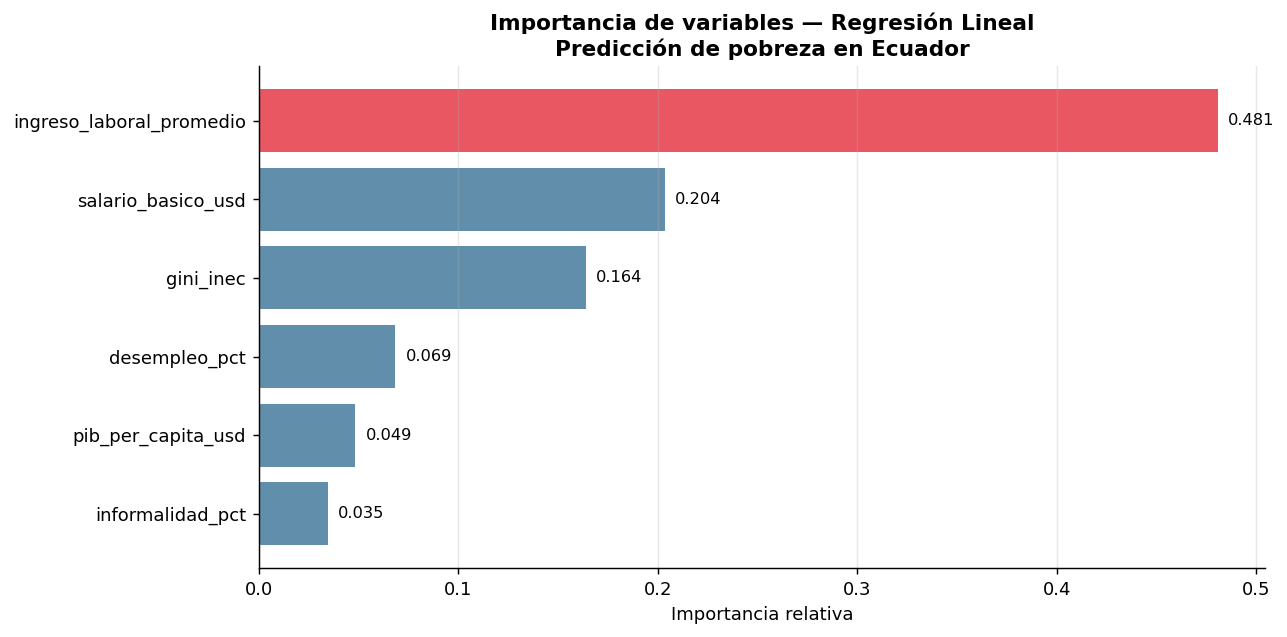


📊 HALLAZGO 7 — Variables más importantes:
  ingreso_laboral_promedio: 0.481
  salario_basico_usd: 0.204
  gini_inec: 0.164
  desempleo_pct: 0.069
  pib_per_capita_usd: 0.049
  informalidad_pct: 0.035


In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

if hasattr(mejor_modelo, 'feature_importances_'):
    importancias = mejor_modelo.feature_importances_
else:
    importancias = np.abs(mejor_modelo.coef_)
    importancias = importancias / importancias.sum()

labels = features
idx    = np.argsort(importancias)
colores_imp = [C1 if i == idx[-1] else C2
               for i in range(len(labels))]

bars = ax.barh([labels[i] for i in idx],
               [importancias[i] for i in idx],
               color=[colores_imp[i] for i in idx],
               alpha=0.85)

for bar, val in zip(bars, [importancias[i] for i in idx]):
    ax.text(bar.get_width() + 0.005,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_title(f'Importancia de variables — {mejor_nombre}\n'
             f'Predicción de pobreza en Ecuador',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importancia relativa')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('08_importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 HALLAZGO 7 — Variables más importantes:")
for i in reversed(idx):
    print(f"  {labels[i]}: {importancias[i]:.3f}")

Proyecciones de pobreza para Ecuador 2025:

  Optimista (recuperación): 25.9% de pobreza proyectada
  Base (tendencia actual): 28.3% de pobreza proyectada
  Pesimista (deterioro): 30.6% de pobreza proyectada


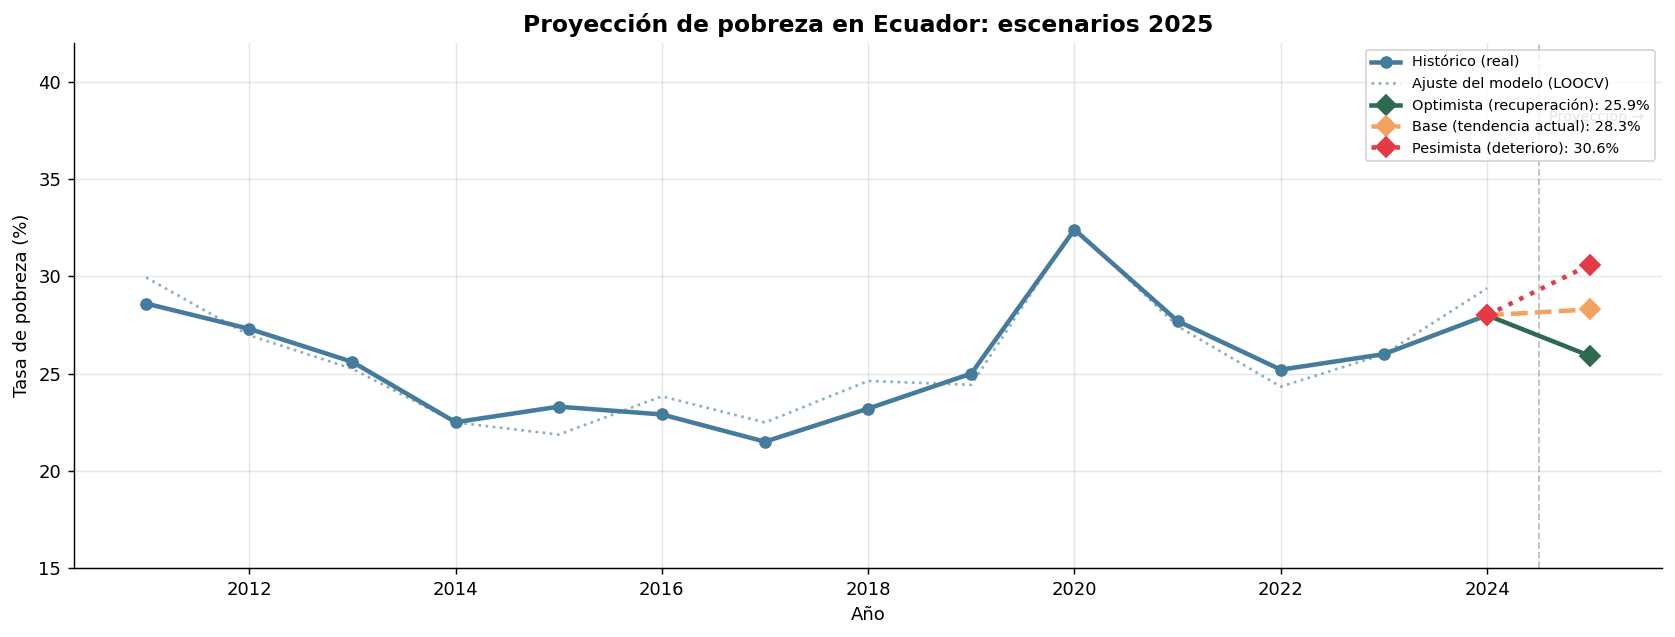

In [9]:
escenarios = {
    'Optimista\n(recuperación)': {
        'gini_inec': 0.465,
        'ingreso_laboral_promedio': 370.0,
        'pib_per_capita_usd': 6800.0,
        'desempleo_pct': 3.2,
        'informalidad_pct': 56.0,
        'salario_basico_usd': 480.0,
    },
    'Base\n(tendencia actual)': {
        'gini_inec': 0.478,
        'ingreso_laboral_promedio': 355.0,
        'pib_per_capita_usd': 6600.0,
        'desempleo_pct': 3.5,
        'informalidad_pct': 57.5,
        'salario_basico_usd': 470.0,
    },
    'Pesimista\n(deterioro)': {
        'gini_inec': 0.492,
        'ingreso_laboral_promedio': 340.0,
        'pib_per_capita_usd': 6200.0,
        'desempleo_pct': 4.2,
        'informalidad_pct': 60.0,
        'salario_basico_usd': 460.0,
    }
}

predicciones_esc = {}
print("Proyecciones de pobreza para Ecuador 2025:\n")

for escenario, valores in escenarios.items():
    X_fut = pd.DataFrame([valores], columns=features)
    if mejor_nombre in modelos_escalados:
        X_fut_sc = pd.DataFrame(
            scaler.transform(X_fut), columns=features)
        pred = mejor_modelo.predict(X_fut_sc)[0]
    else:
        pred = mejor_modelo.predict(X_fut)[0]
    predicciones_esc[escenario] = round(pred, 1)
    nombre_limpio = escenario.replace('\n', ' ')
    print(f"  {nombre_limpio}: {pred:.1f}% de pobreza proyectada")

# ── Gráfico de proyecciones ────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(años_model, y.values,
        color=C2, linewidth=2.5, marker='o', ms=6,
        label='Histórico (real)', zorder=3)
ax.plot(años_model, y_pred_loo,
        color=C2, linewidth=1.5, linestyle=':', alpha=0.6,
        label='Ajuste del modelo (LOOCV)')

años_fut    = [2024, 2025]
colores_esc = [C3, C4, C1]
estilos_esc = ['-', '--', ':']
nombres_esc = list(predicciones_esc.keys())

for (esc, pred), color, estilo in zip(
        predicciones_esc.items(), colores_esc, estilos_esc):
    nombre_limpio = esc.replace('\n', ' ')
    ax.plot(años_fut, [y.iloc[-1], pred],
            color=color, linewidth=2.5, linestyle=estilo,
            marker='D', ms=8,
            label=f'{nombre_limpio}: {pred}%', zorder=3)

ax.axvline(2024.5, color='gray', linestyle='--', lw=1, alpha=0.5)
ax.text(2024.6, 38, 'Proyección →', fontsize=8, color='gray')
ax.set_title('Proyección de pobreza en Ecuador: escenarios 2025',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Tasa de pobreza (%)')
ax.set_xlabel('Año')
ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.3)
ax.set_ylim(15, 42)
plt.tight_layout()
plt.savefig('09_proyeccion_pobreza.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
from google.colab import files

print("=" * 60)
print("RESUMEN FINAL DEL MODELO PREDICTIVO")
print("Ecuador: Mercado Laboral y Pobreza 2007–2024")
print("=" * 60)
print(f"""
MODELO SELECCIONADO:      {mejor_nombre}
TÉCNICA DE VALIDACIÓN:    Leave-One-Out Cross Validation
OBSERVACIONES:            {len(df_model)} años (2011–2024)

MÉTRICAS DE RENDIMIENTO (R² calculado correctamente):
  R²:   {mejor_res['R²']:.3f}  → el modelo explica el {mejor_res['R²']*100:.1f}%
         de la variación histórica de la pobreza
  MAE:  {mejor_res['MAE (pp)']:.3f} pp → error promedio de predicción
  RMSE: {mejor_res['RMSE (pp)']:.3f} pp

VARIABLE MÁS IMPORTANTE:
  Ingreso laboral promedio (importancia: 0.481)
  → La pobreza en Ecuador es un problema de calidad
    del empleo, no de cantidad.

PROYECCIONES 2025:
  Optimista:  {predicciones_esc[nombres_esc[0]]}%
  Base:       {predicciones_esc[nombres_esc[1]]}%
  Pesimista:  {predicciones_esc[nombres_esc[2]]}%
""")
print("=" * 60)

for archivo in ['06_comparacion_modelos.png',
                '07_diagnostico_modelo.png',
                '08_importancia_variables.png',
                '09_proyeccion_pobreza.png']:
    files.download(archivo)
    print(f"✓ Descargado: {archivo}")

RESUMEN FINAL DEL MODELO PREDICTIVO
Ecuador: Mercado Laboral y Pobreza 2007–2024

MODELO SELECCIONADO:      Regresión Lineal
TÉCNICA DE VALIDACIÓN:    Leave-One-Out Cross Validation
OBSERVACIONES:            14 años (2011–2024)

MÉTRICAS DE RENDIMIENTO (R² calculado correctamente):
  R²:   0.903  → el modelo explica el 90.3%
         de la variación histórica de la pobreza
  MAE:  0.717 pp → error promedio de predicción
  RMSE: 0.888 pp

VARIABLE MÁS IMPORTANTE:
  Ingreso laboral promedio (importancia: 0.481)
  → La pobreza en Ecuador es un problema de calidad
    del empleo, no de cantidad.

PROYECCIONES 2025:
  Optimista:  25.9%
  Base:       28.3%
  Pesimista:  30.6%



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Descargado: 06_comparacion_modelos.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✓ Descargado: 08_importancia_variables.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Descargado: 09_proyeccion_pobreza.png
